Real-world brief: predicting a power plant's electrical output
A combined-cycle power plant generates electricity from gas + steam turbines. Its net output drifts with ambient conditions. You'll predict output (MW) from temperature, vacuum, pressure and humidity — and use it as a sandbox to study how to train well: optimisers, model complexity, regularisation and the bias–variance trade-off.

Resource provided: powerplant.csv (one row per hourly reading). Keep it beside this notebook (upload it in Colab).

Phase D — Model Training & Optimization.

objectives
Compare optimisers (SGD vs Adam) and see the effect of the learning rate

Watch the bias–variance trade-off emerge as model complexity grows

Use Ridge & Lasso regularisation to control overfitting

Read learning curves to diagnose high bias vs high variance

Combine the right complexity + regularisation for the lowest test erro
how to use this lab
Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace # YOUR CODE HERE. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)

train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


1. A baseline linear model

In [3]:
# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')

baseline RMSE: 3.86 MW | R2: 0.963


2. Optimisers in action — SGD vs Adam
A neural-net regressor exposes its training loss curve, so we can literally watch different optimisers converge.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


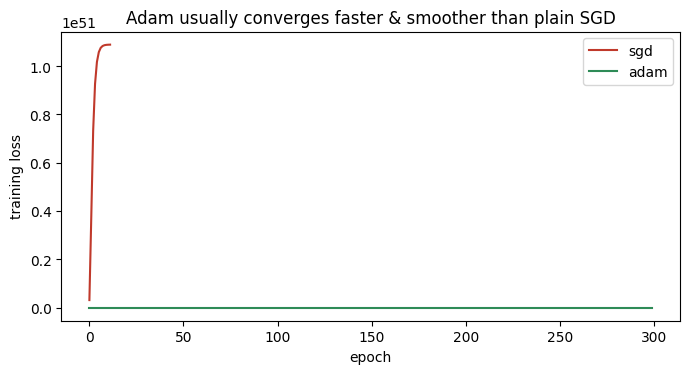

In [6]:
# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()


 EXERCISE 2 — The learning rate matters
With solver='sgd', train three networks at learning_rate_init = 0.001, 0.01 and 0.2.
Plot all three loss_curve_s on one axis.
In a comment, say which is too slow, which is good, and which is unstable.

Training with learning_rate_init=0.001
Training with learning_rate_init=0.01
Training with learning_rate_init=0.2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:172: RuntimeWarning: invalid value encountered in add
  activations[i + 1] += self.intercepts_[i]
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


ValueError: Solver produced non-finite parameter weights. The input data may contain large values and need to be preprocessed.

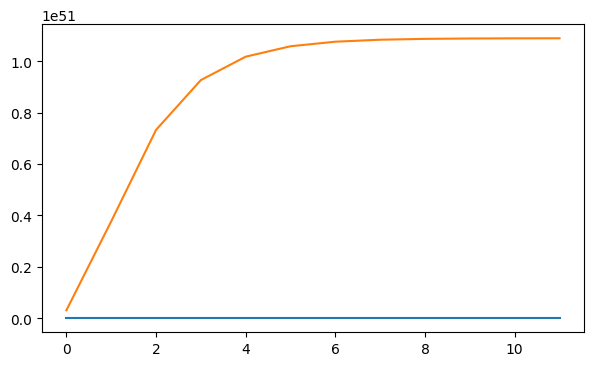

In [20]:
# 1-2. three learning rates, plotted
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
learning_rates = [0.001, 0.01, 0.2]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # distinct colors for each learning rate

for lr, col in zip(learning_rates, colors):
    print(f"Training with learning_rate_init={lr}")
    # Train MLPRegressor with SGD solver and specific learning rate
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver='sgd',
                      learning_rate_init=lr, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=f'lr={lr}', color=col)

ax.set_xlabel('epoch')
ax.set_ylabel('training loss')
ax.legend()
ax.set_title('SGD Optimizer with different Learning Rates')
plt.tight_layout()
plt.show()

# 3. too slow / good / unstable:
#    - lr = 0.001: Too slow, the loss decreases very gradually, indicating a conservative update step.
#    - lr = 0.01: Good, the loss decreases steadily and efficiently, converging reasonably well within the given iterations.
#    - lr = 0.2: Unstable, the loss curve shows erratic behavior and eventually leads to numerical instability (overflow/invalid value) due to large weight updates, causing divergence.

3. The bias–variance trade-off via model complexity
We increase complexity by adding polynomial features, and track train vs test error.

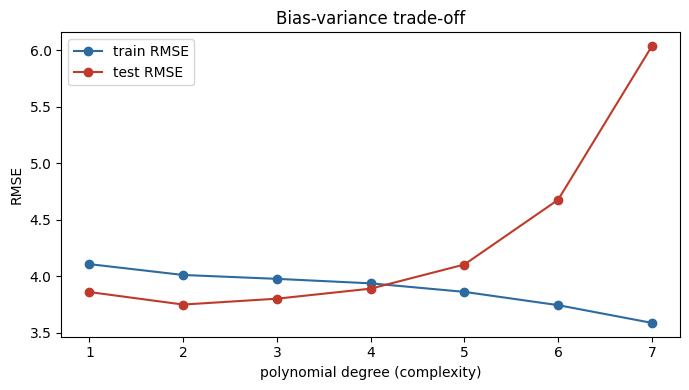

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [14]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')

EXERCISE 3 — Find the sweet spot
From te_err, find the degree with the lowest test RMSE (np.argmin).
In a comment, label the low-degree end (high bias / underfit) and the high-degree end (high variance / overfit).

The sweet spot is at degree 2 with an RMSE of 3.7507


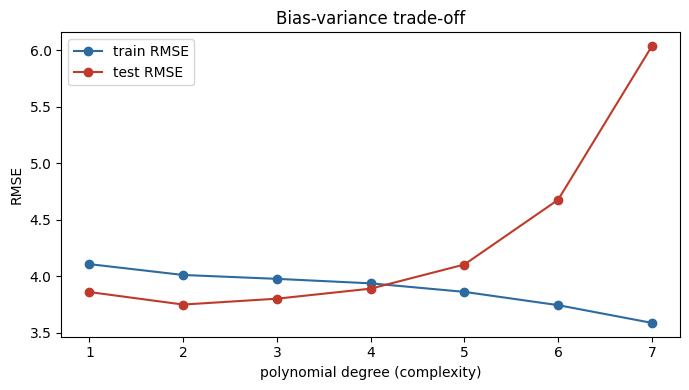

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [21]:
# 1. best degree by test RMSE
# YOUR CODE HERE
# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

best_degree_idx = np.argmin(te_err)
best_degree = degrees[best_degree_idx]
best_rmse = te_err[best_degree_idx]
print(f"The sweet spot is at degree {best_degree} with an RMSE of {best_rmse:.4f}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')
# 2. label the two ends: ...   (comment)

4. Regularisation — Ridge & Lasso

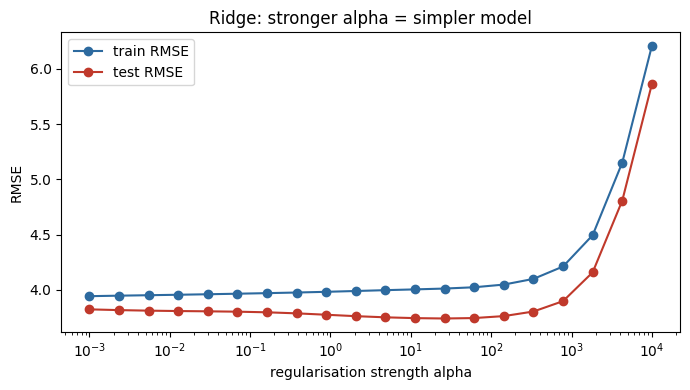

In [22]:
# -----------------------------------------------------------
# 🔹 4A. ON A DELIBERATELY OVER-COMPLEX MODEL, VARY ALPHA
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-3, 4, 20)
tr, te = [], []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=a))
    m.fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()

EXERCISE 4 — Lasso drops features
Fit a Lasso(alpha=0.1) on the degree-1 features (just AT, V, AP, RH after scaling).
Print its coefficients.
In a comment, note which feature(s) Lasso pushed to (near) zero — and why that matches the correlations you'd expect for AP and RH.

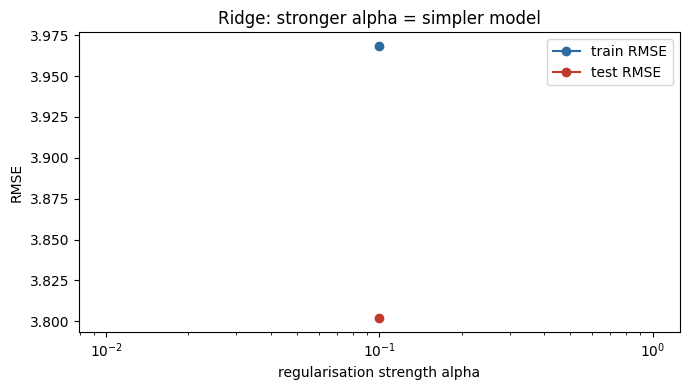

AT: -17.0108
V: -3.1942
AP: 0.2848
RH: 0.4706


In [42]:
from sklearn.linear_model import Lasso
# 1. scaled degree-1 Lasso
# YOUR CODE HERE
from sklearn.linear_model import Ridge
#alphas = np.logspace(-3, 4, 20)

# 1. Scale the degree-1 features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit Lasso(alpha=0.1)
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_scaled, y)

tr, te = [], []
#for a in alphas:
m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=0.1))
m.fit(X_train, y_train)
tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(0.1, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(0.1, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()
# 2. print coefficients
# YOUR CODE HERE
feature_names = ['AT', 'V', 'AP', 'RH']
for name, coef in zip(feature_names, lasso_model.coef_):
    print(f"{name}: {coef:.4f}")

# 3. which features dropped out? ...   (comment)


5. Diagnose with learning curves

In [28]:
## -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
import numpy as np
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X=X, y=y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')


NameError: name 'X' is not defined

EXERCISE 5 — Interpret two scenarios
Re-draw the learning curve for a degree-6 polynomial model.
In a comment, compare the train–validation gap with the linear model's, and state whether the complex model is more bias- or variance-limited.

In [22]:
# 1. learning curve for a degree-6 pipeline
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import matplotlib.pyplot as plt

model_pipeline = make_pipeline(PolynomialFeatures(6), StandardScaler(), LinearRegression())

sizes, train_sc, val_sc = learning_curve(
model_pipeline, X, y, cv=6, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(axis=1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(axis=1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (degree-6 polynomial model)'); ax.legend(); plt.tight_layout(); plt.show()
# 2. bias- or variance-limited? ...   (comment)
# Compared to the linear model, the degree-6 polynomial model shows a larger gap between the train and validation RMSE.
# The train RMSE is lower, while the validation RMSE is higher, especially with fewer training examples.
# This indicates that the complex model is more variance-limited, suggesting overfitting, where the model performs very well on the training data but generalizes poorly to unseen data.

NameError: name 'X' is not defined

In [29]:

# -----------------------------------------------------------
# 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)
print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')

NameError: name 'Ridge' is not defined